# Real Singlet extension of the Standard Model

In [179]:
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import matplotlib.lines as mlines
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import AutoMinorLocator
from matplotlib.colors import TwoSlopeNorm

from cosmoTransitions import pathDeformation, transitionFinder
from cosmoTransitions import pathDeformation

from scipy.optimize import minimize, brentq
from scipy.optimize import minimize_scalar

from xSM_Model import xSM

## Limiting Test: SM

In [7]:
model = xSM()
v = model.v_os
res = minimize_scalar(
    lambda phi: model.Vtot(np.array([[phi, u]]), 0.0).item(),
    bounds=(50, 350),
    method='bounded'
)
v_num = res.x
print(f"Numerical vev (Vtot, T=0): {v_num:.3f} GeV")
print(f"CW shift: {abs(v_num - model.v_os) / model.v_os * 100:.3f}%")

Numerical vev (Vtot, T=0): 246.220 GeV
CW shift: 0.000%


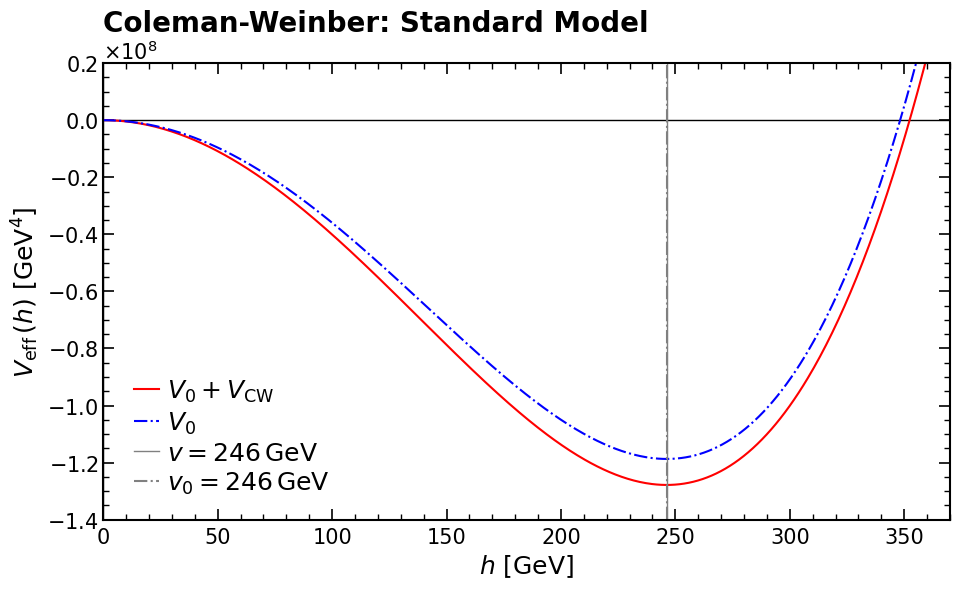

In [16]:
h_vals = np.linspace(-500, 500, 1500)
X = np.column_stack([h_vals, np.zeros_like(h_vals)])

V_tree   = model.V0(X)
V_tot_0  = model.Vtot(X, 0.0)

fig, ax = plt.subplots(figsize=(9.7, 6))

ax.axhline(0, color='k', lw=1, ls='-')
ax.axvline(0, color='k', lw=1, ls='-')

ax.plot(h_vals, V_tot_0-model.Vtot(np.array([[0.0, 0.0]]), 0.0), label=r'$V_0 + V_\mathrm{CW}$', color='r', lw=1.5, ls='-')
ax.plot(h_vals, V_tree-model.V0(np.array([[0.0, 0.0]])), label=r'$V_0$', color='b', lw=1.5, ls='-.')

ax.axvline(v_num, label=rf'$v={float(np.squeeze(v_num)):.0f} \, \mathrm{{GeV}}$', color='gray', lw=1.0, ls='-', alpha=1)
ax.axvline(v, label=rf'$v_0={v:.0f} \, \mathrm{{GeV}}$', color='gray', lw=1.5, ls='-.', alpha=1)

ax.set_xlim(0, 370)
ax.set_ylim(-1.4e8, 2e7)

ax.set_xlabel(r'$h$ $\left[\mathrm{GeV}\right]$', fontsize=18)
ax.set_ylabel(r'$V_\mathrm{eff}\,(h)$ $\left[\mathrm{GeV^4}\right]$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in', length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in', length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()
ax.tick_params(axis='x', which='major', pad=5)

plt.legend(fontsize=18, frameon=True, fancybox=False, loc = "lower left", bbox_to_anchor=(0.01, 0.003),
               ncol = 1, edgecolor="black", framealpha=0, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

plt.title(r"Coleman-Weinber: Standard Model", loc='left', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig("Figures\SM_CW.pdf", format="pdf", bbox_inches="tight")

plt.show()

## Define the Model

In [15]:
def physical_to_lagrangian(m1, m2, theta, v, u, lHS, lS):
    """
    Convert physical parameters to xSM Lagrangian parameters.

    Inputs
    ------
    m1, m2  : scalar mass eigenvalues (GeV), m1 < m2 convention
    theta   : mixing angle (rad)
    v, u    : Higgs and singlet vevs (GeV)
    lHS     : quartic portal lambda_HS
    lS      : singlet quartic lambda_S

    Outputs
    -------
    dict with keys: lH, muHS, mu3, muH2, muS2
    (lHS and lS are inputs, returned unchanged for completeness)
    """
    ct = np.cos(theta)
    st = np.sin(theta)

    # Mass matrix elements from eigenvalues + rotation
    Mhh = m1**2 * ct**2 + m2**2 * st**2
    Mss = m1**2 * st**2 + m2**2 * ct**2
    Mhs = (m1**2 - m2**2) * ct * st

    # Quartic couplings from diagonal mass matrix elements
    lH   = Mhh / (2.0 * v**2)

    # Off-diagonal: Mhs = lHS*v*u + muHS*v  =>  muHS = Mhs/v - lHS*u
    muHS = Mhs / v  -  lHS * u

    # Singlet diagonal: Mss = 2*lS*u^2 - mu3*u - muHS*v^2/(2u)
    # => mu3 = (2*lS*u^2 - Mss - muHS*v^2/(2u)) / u
    if abs(u) > 1e-6:
        mu3 = (2.0*lS*u**2  -  Mss  -  muHS*v**2/(2.0*u)) / u
    else:
        mu3 = 0.0   # u=0: mu3 is unconstrained, set to zero

    # Mass parameters from tadpole conditions
    muH2 = lH*v**2  +  0.5*lHS*u**2  +  muHS*u
    if abs(u) > 1e-6:
        muS2 = 0.5*lHS*v**2  +  muHS*v**2/(2.0*u)  +  lS*u**2  -  mu3*u
    else:
        muS2 = 0.0

    return dict(lH=lH, lHS=lHS, muHS=muHS, lS=lS, mu3=mu3, muH2=muH2, muS2=muS2)

In [375]:
v0 = 246.22
u0 = 100.0
params = physical_to_lagrangian(
    m1    = 125.20,   # GeV  -- SM-like Higgs, fixed
    m2    = 60.0,    # GeV  -- singlet-like scalar, not too heavy
    theta = 0.1,      # rad  -- moderate mixing, enhances cubic
    v     = v0,   # GeV
    u     = u0,     # GeV  -- Careful: If u is small and m2 is light, the potential can be unstable
    lHS   = 0.25,     #      -- portal, moderate
    lS    = 1.0,      #      -- large singlet self-coupling strengthens barrier
)
print(params)

model = xSM(**{k: params[k] for k in ['lH','lHS','muHS','lS','mu3']},
            v=v0, u=u0)
v = model.v_os
u = model.u_os

res = minimize(
    lambda x: model.Vtot(np.array([[x[0], x[1]]]), 0.0).item(),
    x0=[50, 10],          # start from the tree-level vevs
    bounds=[(50, 350), (10, 120)],
    method='L-BFGS-B'
)
v_num, u_num = res.x
print(f"Numerical vevs (Vtot, T=0): v = {v_num:.3f} GeV,  u = {u_num:.3f} GeV")
print(f"CW shift v: {abs(v_num - model.v_os) / model.v_os * 100:.3f}%")
print(f"CW shift u: {abs(u_num - model.u_os) / model.u_os * 100:.3f}%")

{'lH': 0.12828762180611472, 'lHS': 0.25, 'muHS': -20.128462114930556, 'lS': 1.0, 'mu3': 223.81020026568171, 'muH2': 7014.499571030972, 'muS2': -10904.352438088292}
Numerical vevs (Vtot, T=0): v = 246.220 GeV,  u = 100.000 GeV
CW shift v: 0.000%
CW shift u: 0.000%


# Effective Potential at $T=0$

### 1D Plot

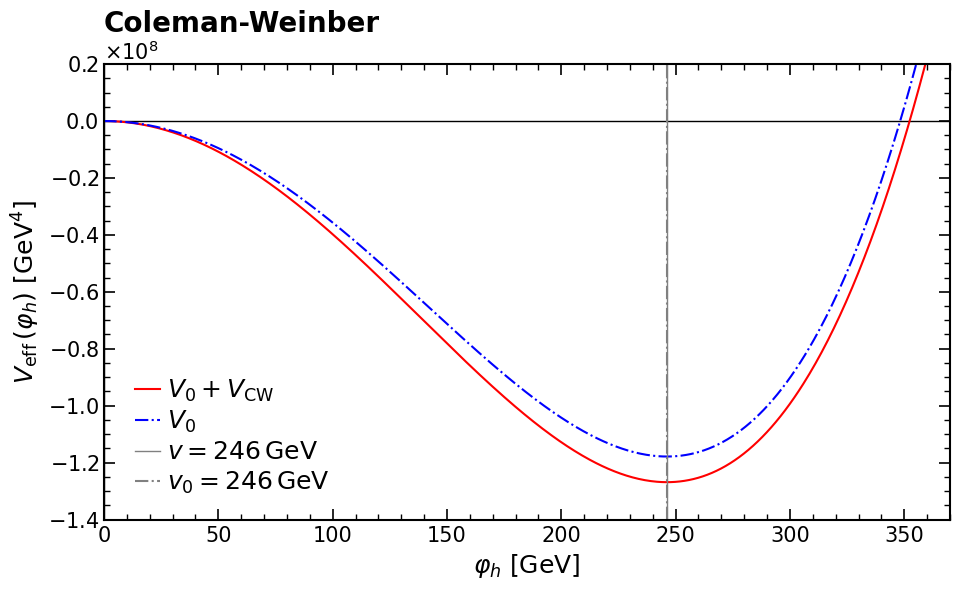

In [391]:
h_vals = np.linspace(-500, 500, 1500)
X = np.column_stack([h_vals, np.zeros_like(h_vals)+u])

V_tree   = model.V0(X)
V_tot_0  = model.Vtot(X, 0.0)

fig, ax = plt.subplots(figsize=(9.7, 6))

ax.axhline(0, color='k', lw=1, ls='-')
ax.axvline(0, color='k', lw=1, ls='-')

ax.plot(h_vals, V_tot_0-model.Vtot(np.array([[0.0, u]]), 0.0), label=r'$V_0 + V_\mathrm{CW}$', color='r', lw=1.5, ls='-')
ax.plot(h_vals, V_tree-model.V0(np.array([[0.0, u]])), label=r'$V_0$', color='b', lw=1.5, ls='-.')

ax.axvline(v_num, label=rf'$v={float(np.squeeze(v_num)):.0f} \, \mathrm{{GeV}}$', color='gray', lw=1.0, ls='-', alpha=1)
ax.axvline(v, label=rf'$v_0={v:.0f} \, \mathrm{{GeV}}$', color='gray', lw=1.5, ls='-.', alpha=1)

ax.set_xlim(0, 370)
ax.set_ylim(-1.4e8, 2e7)

ax.set_xlabel(r'$\varphi_h$ $\left[\mathrm{GeV}\right]$', fontsize=18)
ax.set_ylabel(r'$V_\mathrm{eff}\,(\varphi_h)$ $\left[\mathrm{GeV^4}\right]$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in', length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in', length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()
ax.tick_params(axis='x', which='major', pad=5)

plt.legend(fontsize=18, frameon=True, fancybox=False, loc = "lower left", bbox_to_anchor=(0.01, 0.003),
               ncol = 1, edgecolor="black", framealpha=0, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

plt.title(r"Coleman-Weinber", loc='left', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig("Figures\CW.pdf", format="pdf", bbox_inches="tight")

plt.show()

### 2D Contour Plot

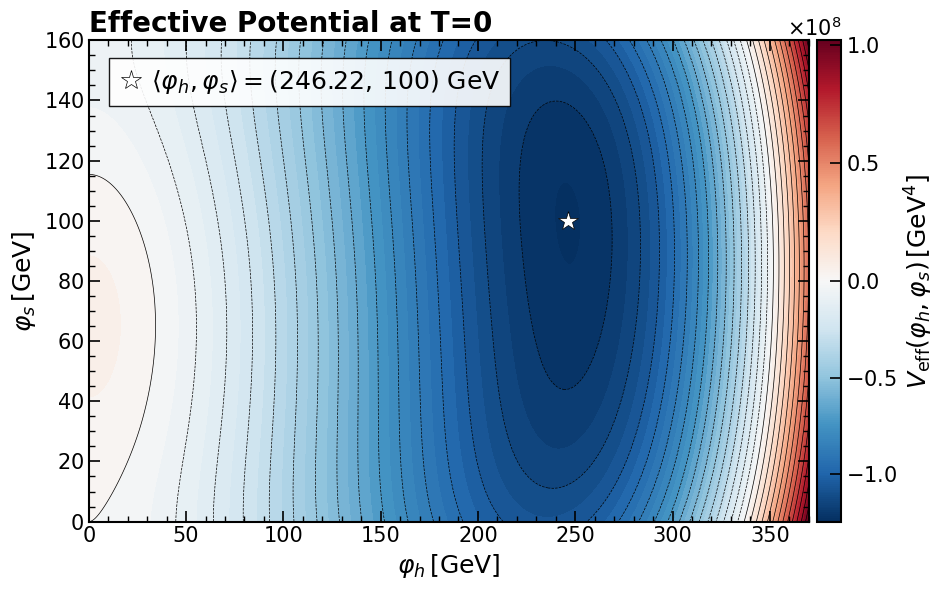

In [416]:
# Grid in (h, s)
h_vals = np.linspace(0, 370, 700)
s_vals = np.linspace(0, 160, 700)
H, S   = np.meshgrid(h_vals, s_vals)
X_grid = np.column_stack([H.ravel(), S.ravel()])
V_grid = model.Vtot(X_grid, 0.0).reshape(H.shape)
V_plot = np.clip(V_grid, np.percentile(V_grid, 0), np.percentile(V_grid, 100))
V_shifted = V_plot - model.Vtot(np.array([[0.0, 0.0]]), 0.0)

norm = TwoSlopeNorm(vcenter=0, vmin=V_shifted.min(), vmax=V_shifted.max())
sm   = ScalarMappable(cmap='RdBu_r', norm=norm)

fig, ax = plt.subplots(figsize=(9.7, 6))

cp = ax.contourf(H, S, V_shifted, levels=60, cmap='RdBu_r', norm=norm)
ax.contour(H, S, V_shifted, levels=30, colors='k', linewidths=0.5, alpha=1)
ax.plot(v_num, u_num, 'w*', markersize=15, zorder=5, markeredgecolor='k', markeredgewidth=0.5,
        label=rf'$\langle\varphi_h, \varphi_s\rangle = ({v_num:.2f},\,{u_num:.0f})$ GeV')

ax.set_xlabel(r'$\varphi_h \, [\mathrm{GeV}]$', fontsize=18)
ax.set_ylabel(r'$\varphi_s \, [\mathrm{GeV}]$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in',
               length=4, width=1,   labelsize=15, top=True, right=True)
ax.minorticks_on()

cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'$V_\mathrm{eff}(\varphi_h,\varphi_s) \, [\mathrm{GeV^4}]$', fontsize=18)
cbar.ax.tick_params(labelsize=15)
cbar.ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
cbar.ax.yaxis.get_offset_text().set_fontsize(15)
plt.ticklabel_format(style='sci', axis='y', scilimits=(-2,3))
for spine in cbar.ax.spines.values():
    spine.set_linewidth(1.5)
cbar.ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15)

ax.legend(fontsize=18, frameon=True, fancybox=False, loc = "upper left", bbox_to_anchor=(0.01, 0.99),
               ncol = 1, edgecolor="black", framealpha=0.9, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

plt.title(r"Effective Potential at T=0", loc='left', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig(r"Figures\CW_contour.pdf", format="pdf", bbox_inches="tight")
plt.show()